In [1]:
import os
import sys

path = os.path.abspath("")
splitted = path.split(os.sep)
user_independent = os.path.join(
    splitted[0] + os.sep, splitted[1], splitted[2], splitted[3]
)
src_path = os.path.join(user_independent, "GitHub", "Photoswitching")
sys.path.append(src_path)

import src.blinking as bl
import src.distributions as dist
import src.emissions as em
import src.fcs as fcs_p
import src.figure as fi
import src.fluorophores as fl
import src.formulas as fo
import src.miscellaneous as mi
import src.network as net
import src.simulation as si
import src.prediction as pr
import src.analysis as an
import src.transitions as tr

import numpy as np
import pandas as pd

%load_ext autoreload
%autoreload 2

import warnings


def custom_warning_format(msg, category, filename, lineno, line=None):
    if line is None:
        import linecache

        line = linecache.getline(filename, lineno)
    return f"WARNING for line: {line} {msg} \n"


warnings.formatwarning = custom_warning_format

In [2]:
fluorophores = fl.construct_fluorophores(
    name="cy5_dna", distance=3, count=1, shape="triangle"
)
fluorophore_system = fl.FluorophoreSystem(fluorophores=fluorophores)

irradiance=2.5
wavelength=640
bleaching=True
energy_transfer=True
reducing_agent="mea"
concentration=100
ph=7.5


In [3]:
transitions = fluorophore_system.load_transitions(
    irradiance=irradiance,
    wavelength=wavelength,
    bleaching=bleaching,
    energy_transfer=energy_transfer,
    dstorm=True,
    dstorm_parameters={'reducing_agent':reducing_agent,
    'concentration':concentration,
    'ph':ph},
)
transition_set = tr.TransitionSet(transitions, fluorophore_system)
transition_set = transition_set.adjust_rates({5:2e4, 4:1e7})
transition_set.finalize()

In [4]:
transition_set.transition_df

transition_type abbreviation  \
Fluorophore identity                                                        
cy5_dna     0                      TransitionType.EXCITATION          EXC   
            1            TransitionType.FLUORESCENT_EMISSION          FLU   
            2         TransitionType.INTERSYSTEM_CROSSING_ST        ISCST   
            3         TransitionType.INTERSYSTEM_CROSSING_TS        ISCTS   
            4                   TransitionType.ISOMERIZATION          ISO   
            5                      TransitionType.PHOTO_BISO        PBISO   
            6                      TransitionType.THERM_BISO        TBISO   
            7           TransitionType.INTERNAL_CONVERSION_S          ICS   
            8                      TransitionType.ET_CYCLE_T          ETT   
            9                      TransitionType.ET_CYCLE_S          ETS   
            10                    TransitionType.REDUCTION_T         REDT   
            11                    TransitionType.REDUCTION_S         REDS   
            12                    TransitionType.OXIDATION_1         OXI1   
            13               TransitionType.PHOTOBLEACHING_1         BLE1   

                         initial_state       final_state          rate  \
Fluorophore identity                                                     
cy5_dna     0           SingleState.S0    SingleState.S1  7.269626e+06   
            1           SingleState.S1    SingleState.S0  1.588235e+08   
            2           SingleState.S1    SingleState.T1  8.300000e+05   
            3           SingleState.T1    SingleState.S0  5.000000e+03   
            4           SingleState.S1   SingleState.Cis  1.000000e+07   
            5          SingleState.Cis    SingleState.S0  2.000000e+04   
            6          SingleState.Cis    SingleState.S0  5.000000e+03   
            7           SingleState.S1    SingleState.S0  4.245818e+08   
            8           SingleState.T1    SingleState.S0  3.065343e+05   
            9           SingleState.S1    SingleState.S0  3.065343e+06   
            10          SingleState.T1  SingleState.OFF1  3.065343e+02   
            11          SingleState.S1  SingleState.OFF1  3.065343e+03   
            12        SingleState.OFF1    SingleState.S0  2.000000e-02   
            13          SingleState.T1     SingleState.B  1.000000e+01   

                      photon fluorophore_ids  absorbing  
Fluorophore identity                                     
cy5_dna     0          False             [0]      False  
            1           True             [0]      False  
            2          False             [0]      False  
            3          False             [0]      False  
            4          False             [0]      False  
            5          False             [0]      False  
            6          False             [0]      False  
            7          False             [0]      False  
            8          False             [0]      False  
            9          False             [0]      False  
            10         False             [0]      False  
            11         False             [0]      False  
            12         False             [0]      False  
            13         False             [0]       True

In [5]:
rng = np.random.default_rng(1)

### Photoswitching fingerprint

In [14]:
num_simulations = 500
all_events_summed = pd.Series(np.zeros(300001), np.linspace(0, 300, 300001))
transition_set = transition_set.adjust_rates({12:2e-2})
transition_set.finalize()
bleaching_times_ox_2em2 = []
no_bleach_ox_2em2 = 0
early_bleach_ox_2em2 = 0

for i in range(num_simulations):
    simulation = si.Simulation(transition_set)
    simulation.run(size=1e6, seed=rng, end_time=300)
    if simulation.transition_series[-1] == 13:
        if simulation.time_series[-2] > 300*1e-3:
            bleaching_times_ox_2em2.append(simulation.time_series[-2])
        else:
            early_bleach_ox_2em2 += 1
    else:
        no_bleach_ox_2em2 += 1
    emis = em.Emissions(frame_time='1ms', bandpass=[665, 731], seed=rng)
    emis.extract(simulation)
    photon_collection_rate = fo.calculate_photon_collection_rate(NA=1.45, n1=1.51)
    emis.add_photon_collection_objective(p=photon_collection_rate, seed=rng) 
    emis.add_transmittance(p=0.9, seed=rng)  # mirror 90/100
    emis.add_transmittance(p=0.99, seed=rng) # lens 1
    emis.add_transmittance(p=0.99, seed=rng) # lens 2
    emis.add_quantum_efficiency(p=0.85, seed=rng)
    emis.add_poisson_noise(rate=0.6, seed=rng)
    emis.apply_threshold(threshold=10)
    all_events_summed = all_events_summed + emis.event_time_series.values

In [15]:
rel_all_events_discard_ox_2em2 = all_events_summed.iloc[300:].cumsum() / all_events_summed.iloc[300:].sum()

In [16]:
num_simulations = 500
all_events_summed = pd.Series(np.zeros(300001), np.linspace(0, 300, 300001))
transition_set = transition_set.adjust_rates({12:2e-1})
transition_set.finalize()
bleaching_times_ox_2em1 = []
no_bleach_ox_2em1 = 0
early_bleach_ox_2em1 = 0

for i in range(num_simulations):
    simulation = si.Simulation(transition_set)
    simulation.run(size=1e6, seed=rng, end_time=300)
    if simulation.transition_series[-1] == 13:
        if simulation.time_series[-2] > 300*1e-3:
            bleaching_times_ox_2em1.append(simulation.time_series[-2])
        else:
            early_bleach_ox_2em1 += 1
    else:
        no_bleach_ox_2em1 += 1
    emis = em.Emissions(frame_time='1ms', bandpass=[665, 731], seed=rng)
    emis.extract(simulation)
    photon_collection_rate = fo.calculate_photon_collection_rate(NA=1.45, n1=1.51)
    emis.add_photon_collection_objective(p=photon_collection_rate, seed=rng) 
    emis.add_transmittance(p=0.9, seed=rng)  # mirror 90/100
    emis.add_transmittance(p=0.99, seed=rng) # lens 1
    emis.add_transmittance(p=0.99, seed=rng) # lens 2
    emis.add_quantum_efficiency(p=0.85, seed=rng)
    emis.add_poisson_noise(rate=0.6, seed=rng)
    emis.apply_threshold(threshold=10)
    all_events_summed = all_events_summed + emis.event_time_series.values

In [17]:
rel_all_events_discard_ox_2em1 = all_events_summed.iloc[300:].cumsum() / all_events_summed.iloc[300:].sum()

In [18]:
num_simulations = 300

all_events_summed = pd.Series(np.zeros(300001), np.linspace(0, 300, 300001))
transition_set = transition_set.adjust_rates({12:2e0})
transition_set.finalize()
bleaching_times_ox_2em0 = []
no_bleach_ox_2em0 = 0
early_bleach_ox_2em0 = 0

for i in range(num_simulations):
    simulation = si.Simulation(transition_set)
    simulation.run(size=1e6, seed=rng, end_time=300)
    if simulation.transition_series[-1] == 13:
        if simulation.time_series[-2] > 300*1e-3:
            bleaching_times_ox_2em0.append(simulation.time_series[-2])
        else:
            early_bleach_ox_2em0 += 1
    else:
        no_bleach_ox_2em0 += 1
    emis = em.Emissions(frame_time='1ms', bandpass=[665, 731], seed=rng)
    emis.extract(simulation)
    photon_collection_rate = fo.calculate_photon_collection_rate(NA=1.45, n1=1.51)
    emis.add_photon_collection_objective(p=photon_collection_rate, seed=rng) 
    emis.add_transmittance(p=0.9, seed=rng)  # mirror 90/100
    emis.add_transmittance(p=0.99, seed=rng) # lens 1
    emis.add_transmittance(p=0.99, seed=rng) # lens 2
    emis.add_quantum_efficiency(p=0.85, seed=rng)
    emis.add_poisson_noise(rate=0.6, seed=rng)
    emis.apply_threshold(threshold=10)
    all_events_summed = all_events_summed + emis.event_time_series.values

In [19]:
rel_all_events_discard_ox_2e0 = all_events_summed.iloc[300:].cumsum() / all_events_summed.iloc[300:].sum()

In [12]:
num_simulations = 300
all_events_summed = pd.Series(np.zeros(300001), np.linspace(0, 300, 300001))
transition_set = transition_set.adjust_rates({12:2e1})
transition_set.finalize()
bleaching_times_ox_2e1 = []
no_bleach_ox_2e1 = 0
early_bleach_ox_2e1 = 0

for i in range(num_simulations):
    simulation = si.Simulation(transition_set)
    simulation.run(size=1e6, seed=rng, end_time=300)
    if simulation.transition_series[-1] == 13:
        if simulation.time_series[-2] > 300*1e-3:
            bleaching_times_ox_2e1.append(simulation.time_series[-2])
        else:
            early_bleach_ox_2e1 += 1
    else:
        no_bleach_ox_2e1 += 1
    emis = em.Emissions(frame_time='1ms', bandpass=[665, 731], seed=rng)
    emis.extract(simulation)
    photon_collection_rate = fo.calculate_photon_collection_rate(NA=1.45, n1=1.51)
    emis.add_photon_collection_objective(p=photon_collection_rate, seed=rng) 
    emis.add_transmittance(p=0.9, seed=rng)  # mirror 90/100
    emis.add_transmittance(p=0.99, seed=rng) # lens 1
    emis.add_transmittance(p=0.99, seed=rng) # lens 2
    emis.add_quantum_efficiency(p=0.85, seed=rng)
    emis.add_poisson_noise(rate=0.6, seed=rng)
    emis.apply_threshold(threshold=10)
    all_events_summed = all_events_summed + emis.event_time_series.values

In [13]:
rel_all_events_discard_ox_2e1 = all_events_summed.iloc[300:].cumsum() / all_events_summed.iloc[300:].sum()

In [73]:
from scipy.stats import expon
def estimate_lambda(bleaching_times, no_bleach):
    t_b_max = np.max(bleaching_times)
    p = len(bleaching_times) / (len(bleaching_times) + no_bleach)
    if p == 1:
        lambda_ = 1/np.mean(bleaching_times)
    else:
        lambda_ = - np.log(1 - p) / t_b_max


    return lambda_

In [74]:
x = np.linspace(0, 300, 297401)
lambda_ox_2em2 = estimate_lambda(bleaching_times_ox_2em2, no_bleach_ox_2em2)
lambda_ox_2em1 = estimate_lambda(bleaching_times_ox_2em1, no_bleach_ox_2em1)
lambda_ox_2em0 = estimate_lambda(bleaching_times_ox_2em0, no_bleach_ox_2em0)
lambda_ox_2e1 = estimate_lambda(bleaching_times_ox_2e1, no_bleach_ox_2e1)
cdf_ox_2em2 = expon.cdf(x=x, scale=1/lambda_ox_2em2)
cdf_ox_2em1 = expon.cdf(x=x, scale=1/lambda_ox_2em1)
cdf_ox_2em0 = expon.cdf(x=x, scale=1/lambda_ox_2em0)
cdf_ox_2e1 = expon.cdf(x=x, scale=1/lambda_ox_2e1)
cdf_ox_2em2 /= cdf_ox_2em2[-1]
cdf_ox_2em1 /= cdf_ox_2em1[-1]
cdf_ox_2em0 /= cdf_ox_2em0[-1]
cdf_ox_2e1 /= cdf_ox_2e1[-1]


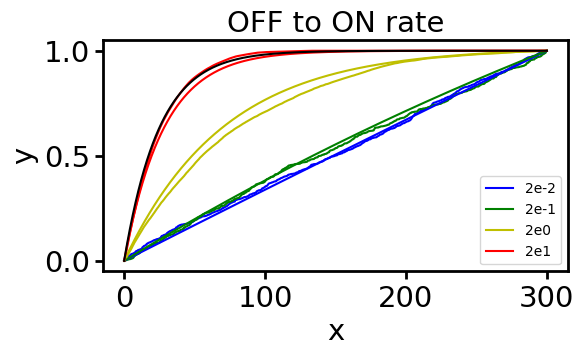

In [95]:
ax = fi.universal_figure(data=[all_events_summed.index[:-300][::10000], rel_all_events_discard_ox_2em2[::10000]], 
                        label='2e-2', marker='x', linestyle='')
fi.universal_figure(data=[all_events_summed.index[:-300][::10000], rel_all_events_discard_ox_2em1[::10000]],
                    axes=ax[0], color='g', label='2e-1', marker='x', linestyle='')
fi.universal_figure(data=[all_events_summed.index[:-300][::10000], rel_all_events_discard_ox_2e0[::10000]],
                    axes=ax[0], color='y', label='2e0', marker='x', linestyle='')
fi.universal_figure(data=[x, cdf_ox_2em2], axes=ax[0], color='b')
fi.universal_figure(data=[x, cdf_ox_2em1], axes=ax[0], color='g')
fi.universal_figure(data=[x, cdf_ox_2em0], axes=ax[0], color='y')
fi.universal_figure(data=[x, cdf_ox_2e1], axes=ax[0], color='r')
fi.universal_figure(data=[all_events_summed.index[:-300][::10000], rel_all_events_discard_ox_2e1[::10000]], 
                    title='OFF to ON rate', ylabel='% emission', xlabel='time (s)', marker='x', linestyle='',
                    axes=ax[0], color='r', label='2e1', legend=True)
fig = mi.get_figure(ax)
# fig.savefig("OFF_ON_rate_cum_locs.svg")